In [4]:
# Problem: Time Series Forecasting of stock prices with ARIMA model
# Dataset: https://www.kaggle.com/datasets/soumendraprasad/stock

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings('ignore')

Text(0, 0.5, 'Close Price')

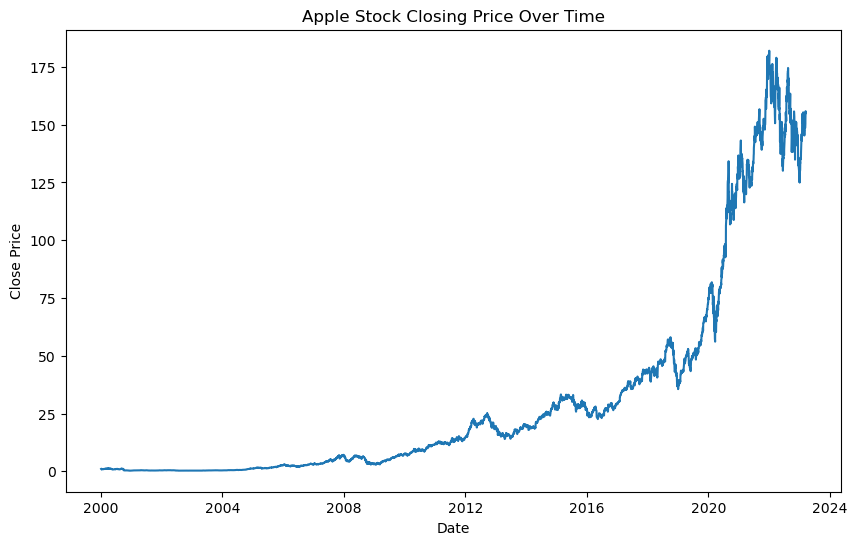

In [5]:
# Step 1: Load the data and preprocess
data = pd.read_csv('Apple.csv')

# Convert date to datetime format and set it as the index.
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# Plot the closing price to visualize the time series.
plt.figure(figsize=(10, 6))
plt.plot(data['Close'], label='Apple stock closing price')
plt.title('Apple Stock Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
# plt.show()


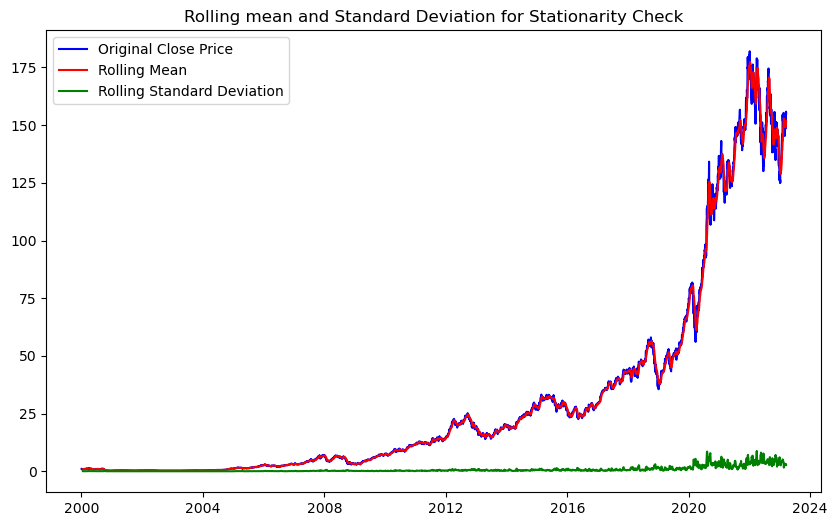

In [6]:
# Step 2: Check for Stationary
# We'll check for stationarity using a rolling mean and standard deviation.
# Rolling mean: It's like looking at the data through a moving window, where each point represents the average of
# recent values.
# Rolling standard deviation: This is similar to the rolling mean, but instead of averaging, it measures how spread
# out the numbers are within each moving window:
rolling_mean = data['Close'].rolling(window=12).mean()
rolling_std = data['Close'].rolling(window=12).std()

# Plot rolling statistics
plt.figure(figsize=(10, 6))
plt.plot(data['Close'], color='blue', label='Original Close Price')
plt.plot(rolling_mean, color='red', label='Rolling Mean')
plt.plot(rolling_std, color='green', label='Rolling Standard Deviation')
plt.title('Rolling mean and Standard Deviation for Stationarity Check')
plt.legend()
# plt.show()

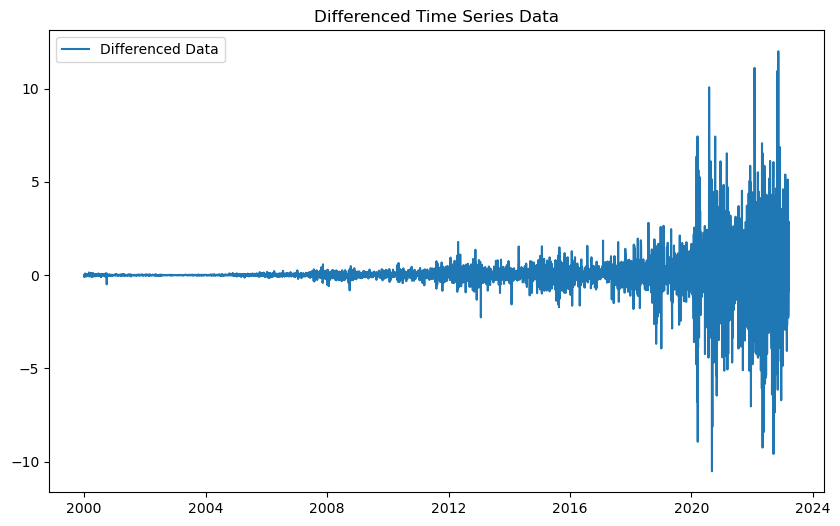

In [7]:
# Step 3: Differencing the data to make it stationary
# If the data is not stationary, we’ll apply differencing to remove trends and seasonality.
data_diff = data['Close'].diff().dropna()

# Plot the differenced data.
plt.figure(figsize=(10, 6))
plt.plot(data_diff, label='Differenced Data')
plt.title('Differenced Time Series Data')
plt.legend()
# plt.show()

In [8]:
# Step 4: Build and Train the ARIMA Model
model = ARIMA(data['Close'], order=(5, 1, 0))
#  The (p, d, q) parameters define the structure of the ARIMA mode.
#
# p (Autoregressive term):
# This represents the number of lag observations in the model.
# In your example, p = 5 means the model will use the 5 previous time steps to predict the current value.
#
# d (Integrated or Differencing term):
# This represents the number of times the raw observations are differenced.
# In your example, d = 1 means the data will be differenced once to make it stationary.
#
# q (Moving Average term):
# This represents the size of the moving average window.
# In your example, q = 0 means there is no moving average component in this model.
model_fit = model.fit()


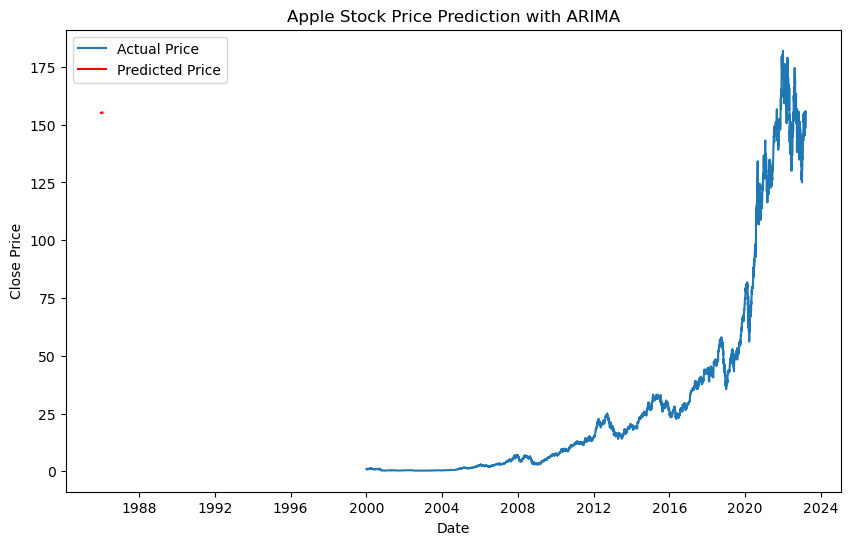

In [9]:
# Step 5: Make Predictions.
forecast = model_fit.forecast(steps=30) # Forecast for 30 days ahead.
plt.figure(figsize=(10, 6))
plt.plot(data['Close'], label='Actual Price')
plt.plot(forecast, label='Predicted Price', color='red')
plt.title('Apple Stock Price Prediction with ARIMA')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()